In [1]:
import os, sys
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colors, cm
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.ticker import MaxNLocator
import seaborn as sns
from scipy.stats import bootstrap
from matplotlib.patches import Patch
from shapely import wkt

In [2]:
module_path = "../src"
sys.path.append(os.path.abspath(module_path))
from results_analysis_tc import *
# from percolation_analysis_tc import *

In [3]:
# INPUT PARAMETERS
base_dir = f"../outputs/20250725_hazard_iter_1000"

output_dir = "../figures/20250725_hazard_iter_1000"
os.makedirs(output_dir, exist_ok=True)

In [4]:
lines_gdf = gpd.read_file('../outputs/table_lines_200m_update_remove_disconnected.gpkg')
nodes_gdf = gpd.read_file('../outputs/table_nodes_200m_update_remove_disconnected.gpkg')
loads_gdf = gpd.read_file('../outputs/landuse_sites_gdf_add_bus.gpkg')
gens_gdf = gpd.read_file('../outputs/plant_update.gpkg')
basemap = gpd.read_file("../data/base_map/vnm_admbnda_adm1_gov_20201027.shp")

overload_lines_df = pd.read_csv(f"{base_dir}/overloaded_lines_records.csv")
failed_lines_df = pd.read_csv(f"{base_dir}/failed_lines_records.csv")
failed_nodes_df = pd.read_csv(f"{base_dir}/failed_buses_records.csv")
# load_ratio_df = pd.read_csv(f"{base_dir}/load_served_ratio.csv")
load_status_df = pd.read_csv(f"{base_dir}/load_status_records.csv")
results_df = pd.read_csv(f"{base_dir}/percolation_overall_results.csv")


In [5]:
basemap.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [5]:
nodes_gdf, lines_gdf, loads_gdf = assign_adm1_codes_with_ref_and_pcode(nodes_gdf, lines_gdf, loads_gdf, basemap)

In [ ]:
# def plot_failure_impact_maps(lines_gdf_sim_update, nodes_gdf_sim_update, basemap, fig_path):
#     """
#     For each impact_* column, generate a 2-panel map showing failure status of lines and buses.
#     """
#     os.makedirs(fig_path, exist_ok=True)

#     # 提取所有 impact_* 列
#     impact_cols = [col for col in lines_gdf_sim_update.columns if col.startswith("impact_")]

#     # 区域底图划分
#     pcode_list = ['VN106', 'VN111', 'VN101', 'VN107', 'VN103', 'VN109', 'VN113', 'VN117', 'VN115', 'VN104']
#     target_regions = basemap[basemap["ADM1_PCODE"].isin(pcode_list)]
#     other_regions = basemap[~basemap["ADM1_PCODE"].isin(pcode_list)]

#     # 状态颜色映射
#     # Colorblind friendly color schemes: https://scottplot.net/cookbook/4.1/colors/#category-20
#     # status_colors = {
#     #     'Not Failed': '#00B25D',
#     #     'Direct Failed': '#B51D14',
#     #     'Indirect Failed': '#4053D3'
#     # }
#     status_colors = {
#         'Not Failed': '#98DF8A',
#         'Direct Failed': '#D62728',
#         'Indirect Failed': '#1F77B4'
#     }

#     for impact_column in impact_cols:
#         fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#         # ========== 左图：线路 ========== #
#         ax = axes[0]
#         for status, color in status_colors.items():
#             subset = lines_gdf_sim_update[lines_gdf_sim_update[impact_column] == status]
#             if not subset.empty:
#                 subset.plot(ax=ax, color=color, linewidth=1.5, label=status, zorder=3)

#         target_regions.plot(ax=ax, color='lightgray', edgecolor='white', linewidth=0.5, alpha=0.5, zorder=1)
#         other_regions.plot(ax=ax, color='white', edgecolor='lightgray', linewidth=0.3, zorder=0)

#         ax.set_title("Line failure status", fontsize=13)
#         ax.set_xlim(105, 107.5)
#         ax.set_ylim(19.85, 21.7)
#         ax.set_aspect('auto')
#         ax.tick_params(axis='both', which='major', labelsize=12)
#         ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
#         ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
#         ax.set_xlabel("Longitude", fontsize=13)
#         ax.set_ylabel("Latitude", fontsize=13)
#         ax.legend(loc='lower right', fontsize=13)

#         # ========== 右图：节点 ========== #
#         ax = axes[1]
#         for status, color in status_colors.items():
#             subset = nodes_gdf_sim_update[nodes_gdf_sim_update[impact_column] == status]
#             if not subset.empty:
#                 subset.plot(ax=ax, color=color, markersize=15, label=status, zorder=3)

#         target_regions.plot(ax=ax, color='lightgray', edgecolor='white', linewidth=0.5, alpha=0.5, zorder=1)
#         other_regions.plot(ax=ax, color='white', edgecolor='lightgray', linewidth=0.3, zorder=0)

#         ax.set_title("Bus failure status", fontsize=13)
#         ax.set_xlim(105, 107.5)
#         ax.set_ylim(19.85, 21.7)
#         ax.set_aspect('auto')
#         ax.tick_params(axis='both', which='major', labelsize=12)
#         ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
#         ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
#         ax.tick_params(labelleft=False)
#         ax.set_xlabel("Longitude", fontsize=13)
#         ax.legend(loc='lower right', fontsize=13)

#         # 显示 iteration 编号
#         iter = impact_column.split("_")[-1]
#         ax.text(
#             0.95, 0.95,
#             f"Iteration {iter}",
#             transform=ax.transAxes,
#             ha="right", va="top",
#             fontsize=13,
#             bbox=dict(boxstyle="round,pad=0.3", edgecolor="gray", facecolor="white", alpha=0.4)
#         )

#         plt.tight_layout()
#         output_file = os.path.join(fig_path, f"{impact_column}_results.png")
#         plt.savefig(output_file, dpi=600, bbox_inches="tight")
#         plt.close()
#         print(f"✓ Saved: {output_file}")

In [ ]:
# 读取 Excel 为 DataFrame
lines_df = pd.read_excel(f"{base_dir}/lines_gdf_sim_update.xlsx")
nodes_df = pd.read_excel(f"{base_dir}/nodes_gdf_sim_update.xlsx")

# 将 WKT 字符串转换为 Shapely geometry
lines_df["geometry"] = lines_df["geometry"].apply(wkt.loads)
nodes_df["geometry"] = nodes_df["geometry"].apply(wkt.loads)

# 转为 GeoDataFrame
lines_gdf_sim_update = gpd.GeoDataFrame(lines_df, geometry="geometry", crs="EPSG:4326")  # 视情况调整 CRS
nodes_gdf_sim_update = gpd.GeoDataFrame(nodes_df, geometry="geometry", crs="EPSG:4326")  # 视情况调整 CRS

In [12]:
# plot_failure_impact_maps(lines_gdf_sim_update, nodes_gdf_sim_update, basemap, fig_path=output_dir)

In [ ]:
lines_gdf_update = compute_failure_probabilities(lines_gdf_sim_update)
nodes_gdf_update = compute_failure_probabilities(nodes_gdf_sim_update)

In [ ]:
# lines_gdf = lines_gdf.drop(columns=["overload_count", "overload_prob","overload_count"], errors="ignore")

In [5]:
# Merge overload ratio stats
# === Step 1: 统计每条线路超载次数 ===
overload_count = overload_lines_df.groupby("line_name").size().rename("overload_count").reset_index()
# 真实参与仿真的总次数（成功且线路有结果）
sim_combinations = overload_lines_df["fail_iter"].drop_duplicates()
num_simulations = sim_combinations.shape[0]

overload_count["overload_prob"] = overload_count["overload_count"] / num_simulations
overload_count = overload_count.sort_values("overload_prob", ascending=False)
overload_count.to_csv(os.path.join(base_dir, "overloaded_line_stats.csv"))

lines_gdf = lines_gdf.merge(overload_count.rename(columns={"line_name": "LineID"}), on="LineID", how="left")
lines_gdf["overload_prob"] = lines_gdf["overload_prob"].fillna(0)

In [6]:
def plot_overload_histogram(lines_with_ratio, output_dir, basemap):
    """
    Plot overload ratios across all ADM1_REF regions.
    """
    os.makedirs(output_dir, exist_ok=True)
    lines_with_ratio = lines_with_ratio.to_crs("EPSG:4326")
    basemap = basemap.to_crs("EPSG:4326")

    # Histogram of overload ratio bins (vs. total lines)
    bins = np.arange(0.01, 1.01, 0.1)
    lines_with_ratio["overload_prob"] = lines_with_ratio["overload_prob"].fillna(0)

    total_lines_all = len(lines_with_ratio)
    lines_positive = lines_with_ratio[lines_with_ratio["overload_prob"] > 0]

    counts, bin_edges = np.histogram(lines_positive["overload_prob"], bins=bins)
    bin_labels = [f"{round(bin_edges[i],1)}–{round(bin_edges[i+1],1)}" for i in range(len(counts))]
    proportions = [f"{(c/total_lines_all*100):.2f}%" for c in counts]

    plt.figure(figsize=(9, 6))
    bars = plt.bar(bin_labels, counts, color="skyblue", edgecolor="lightgray")
    plt.xlabel("Overload probability interval (excl. 0)", fontsize=13)
    plt.ylabel("Number of lines", fontsize=13)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.title("Overload probability distribution (% of all lines)", fontsize=13)
    plt.grid(axis="y", linestyle="--", alpha=0.7)

    for bar, pct in zip(bars, proportions):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, height + 0.5, pct,
                 ha="center", va="bottom", fontsize=12, fontweight="bold")

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "overload_prob_hist_vs_all_lines.png"), dpi=600)


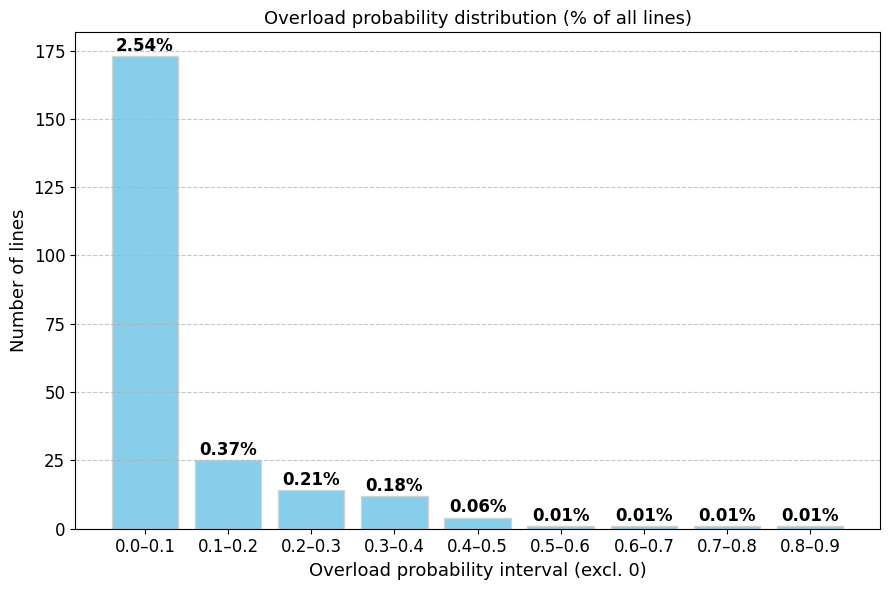

In [17]:
plot_overload_histogram(lines_gdf, output_dir, basemap)

In [10]:
lines_gdf.head(2)

,LineID,Country,osm_id,fromNode,toNode,voltage,Length,std_type,apprent_power,max_i_ka,...,ID_node1_final,lon1_final,lat1_final,ID_node2_final,lon2_final,lat2_final,disconnected,geometry,overload_count,overload_prob
0,LINEVN0001a,VN,153608701,NODEVN3270a,NODEVN0001,110.0,2.692679,490-AL1/64-ST1A 110.0,182.904565,0.96,...,153608703.0,610714.852695,2.315181e+06,1.0,609979.512105,2.317122e+06,no,"LINESTRING (610714.853 2315180.7, 610719.861 2...",609.0,0.983845
1,LINEVN0001b,VN,153608701,NODEVN3270a,NODEVN0001,110.0,2.692679,490-AL1/64-ST1A 110.0,182.904565,0.96,...,153608703.0,610714.852695,2.315181e+06,1.0,609979.512105,2.317122e+06,no,"LINESTRING (610714.853 2315180.7, 610719.861 2...",609.0,0.983845


In [21]:
def normalize_line_records(df):
    """
    Normalize failed / overloaded line records to:
    columns = ['iter', 'line']
    """

    out = df.copy()

    # 1. iteration: fail_iter -> integer
    # e.g. 'fail_iter_123' -> 123
    out["iter"] = (
        out["fail_iter"]
        .astype(str)
        .str.extract(r"(\d+)")
        .astype(int)
    )

    # 2. line identifier
    out["line"] = out["line_name"].astype(str)

    # 3. keep minimal columns & deduplicate
    out = out[["iter", "line"]].drop_duplicates().reset_index(drop=True)

    return out


def cooccurrence_diagnostics_from_df(
    failed_lines_df,
    overload_lines_df,
    top_lines=None,
    top_n=10,
    k_associated=10,
    output_dir=None,
):
    """
    Diagnose co-occurrence between overloaded lines and failed lines.
    Tailored to records with columns: fail_iter, line_name.
    """

    # --- normalize ---
    failed = normalize_line_records(failed_lines_df)
    overload = normalize_line_records(overload_lines_df)

    # --- universe of iterations ---
    iters = sorted(set(failed["iter"]).union(set(overload["iter"])))
    n_iters = len(iters)

    print(f"[INFO] Total iterations detected: {n_iters}")

    # --- build iteration sets ---
    failed_iters_by_line = failed.groupby("line")["iter"].apply(set).to_dict()
    overload_iters_by_line = overload.groupby("line")["iter"].apply(set).to_dict()

    # --- determine top overloaded lines ---
    if top_lines is None:
        freq = pd.Series(
            {l: len(s) / n_iters for l, s in overload_iters_by_line.items()},
            name="p_overload"
        )
        top_lines = (
            freq.sort_values(ascending=False)
                .head(top_n)
                .index
                .tolist()
        )

    # --- overview table ---
    top_overview = []
    for L in top_lines:
        oset = overload_iters_by_line.get(L, set())
        top_overview.append({
            "top_overloaded_line": L,
            "n_overload_iters": len(oset),
            "p_overload": len(oset) / n_iters
        })

    top_overview = (
        pd.DataFrame(top_overview)
        .sort_values("p_overload", ascending=False)
        .reset_index(drop=True)
    )

    # --- co-occurrence diagnostics ---
    rows = []

    for L in top_lines:
        oset = overload_iters_by_line.get(L, set())
        n_over = len(oset)

        if n_over == 0:
            continue

        for F, fset in failed_iters_by_line.items():
            n_fail = len(fset)
            if n_fail == 0:
                continue

            A = len(oset & fset)   # overload AND failed
            if A == 0:
                continue

            B = n_over - A
            C = n_fail - A
            D = n_iters - (A + B + C)

            p_over_given_fail = A / n_fail
            p_over_given_notfail = (
                B / (n_iters - n_fail) if (n_iters - n_fail) > 0 else np.nan
            )

            risk_ratio = (
                p_over_given_fail / p_over_given_notfail
                if p_over_given_notfail not in [0, np.nan] else np.inf
            )

            p_over = n_over / n_iters
            p_fail = n_fail / n_iters
            lift = (A / n_iters) / (p_over * p_fail)

            denom = np.sqrt((A+B)*(C+D)*(A+C)*(B+D))
            phi = (A*D - B*C) / denom if denom > 0 else np.nan

            rows.append({
                "top_overloaded_line": L,
                "failed_line": F,
                "A_over_and_fail": A,
                "p_overload_given_failed": p_over_given_fail,
                "p_overload_given_not_failed": p_over_given_notfail,
                "risk_ratio": risk_ratio,
                "lift": lift,
                "phi": phi
            })

    summary = pd.DataFrame(rows)

    summary_top = (
        summary.sort_values(
            ["top_overloaded_line", "lift", "phi", "risk_ratio"],
            ascending=[True, False, False, False]
        )
        .groupby("top_overloaded_line", as_index=False)
        .head(k_associated)
        .reset_index(drop=True)
    )

    # --- save ---
    if output_dir is not None:
        os.makedirs(output_dir, exist_ok=True)
        top_overview.to_csv(
            os.path.join(output_dir, "top_overloaded_lines_overview.csv"),
            index=False
        )
        summary_top.to_csv(
            os.path.join(output_dir, "top_overloaded_lines_associated_failed_lines.csv"),
            index=False
        )

    return summary_top, top_overview


In [ ]:
summary_top, top_overview = cooccurrence_diagnostics_from_df(
    failed_lines_df=failed_lines_df,
    overload_lines_df=overload_lines_df,
    top_lines=None,
    top_n=10,
    k_associated=10,
    output_dir=output_dir
)

summary_top.head()

[INFO] Total iterations detected: 1000


,top_overloaded_line,failed_line,A_over_and_fail,p_overload_given_failed,p_overload_given_not_failed,risk_ratio,lift,phi
0,LINEVN0001a,LINEVN0460a,7,0.875000,0.606855,1.441860,1.436782,0.048952
1,LINEVN0001a,LINEVN0460b,7,0.875000,0.606855,1.441860,1.436782,0.048952
2,LINEVN0001a,LINEVN0201,8,0.800000,0.607071,1.317804,1.313629,0.039339
3,LINEVN0001a,LINEVN0202,8,0.800000,0.607071,1.317804,1.313629,0.039339
4,LINEVN0001a,LINEVN1617,22,0.758621,0.604531,1.254890,1.245683,0.052989


In [23]:
summary_top

,top_overloaded_line,failed_line,A_over_and_fail,p_overload_given_failed,p_overload_given_not_failed,risk_ratio,lift,phi
0,LINEVN0001a,LINEVN0460a,7,0.875000,0.606855,1.441860,1.436782,0.048952
1,LINEVN0001a,LINEVN0460b,7,0.875000,0.606855,1.441860,1.436782,0.048952
2,LINEVN0001a,LINEVN0201,8,0.800000,0.607071,1.317804,1.313629,0.039339
3,LINEVN0001a,LINEVN0202,8,0.800000,0.607071,1.317804,1.313629,0.039339
4,LINEVN0001a,LINEVN1617,22,0.758621,0.604531,1.254890,1.245683,0.052989
...,...,...,...,...,...,...,...,...
95,LINEVN5686,LINEVN0202,8,0.800000,0.617172,1.296236,1.292407,0.037459
96,LINEVN5686,LINEVN1617,23,0.793103,0.613800,1.292120,1.281266,0.061957
97,LINEVN5686,LINEVN0459a,12,0.750000,0.616870,1.215815,1.211632,0.034397
98,LINEVN5686,LINEVN0459b,12,0.750000,0.616870,1.215815,1.211632,0.034397


In [7]:
def get_top10_overload_lines(
    lines_with_ratio,
    output_dir=None,
    prob_col="overload_prob",
    crs_out="EPSG:4326",
    save_gpkg=True,
    save_csv=True,
):
    """
    Extract top 10 transmission lines with highest failure / overload probability.

    Parameters
    ----------
    lines_with_ratio : GeoDataFrame
        Transmission lines with failure probability attribute.
    output_dir : str or None
        Directory to save outputs. If None, only return GeoDataFrame.
    prob_col : str
        Column name for failure probability.
    crs_out : str
        Output CRS.
    save_gpkg : bool
        Save as GeoPackage.
    save_csv : bool
        Save as CSV (geometry dropped).

    Returns
    -------
    gdf_top10 : GeoDataFrame
        Top 10 lines by failure probability.
    """

    gdf = lines_with_ratio.copy()
    gdf = gdf.to_crs(crs_out)

    # Safety: fill NA with 0
    gdf[prob_col] = gdf[prob_col].fillna(0)

    # Sort and select top 10
    gdf_top10 = (
        gdf.sort_values(prob_col, ascending=False)
           .head(10)
           .reset_index(drop=True)
    )

    # Add ranking
    gdf_top10["rank"] = range(1, len(gdf_top10) + 1)

    if output_dir is not None:
        os.makedirs(output_dir, exist_ok=True)

        if save_gpkg:
            gpkg_path = os.path.join(output_dir, "top10_failure_lines.gpkg")
            gdf_top10.to_file(gpkg_path, layer="top10_lines", driver="GPKG")

        if save_csv:
            csv_path = os.path.join(output_dir, "top10_failure_lines.csv")
            gdf_top10.drop(columns="geometry").to_csv(csv_path, index=False)

    return gdf_top10


def plot_top10_overload_lines(
    gdf_top10,
    basemap=None,
    output_dir=None,
    fname="top10_failure_lines_map.png",
):
    """
    Plot top 10 failure probability lines on a map.
    """

    fig, ax = plt.subplots(1, 1, figsize=(8, 10))

    if basemap is not None:
        basemap = basemap.to_crs(gdf_top10.crs)
        basemap.plot(ax=ax, color="lightgrey", linewidth=0.3)

    gdf_top10.plot(
        ax=ax,
        column="overload_prob",
        cmap="Reds",
        linewidth=2.5,
        legend=True,
        legend_kwds={"label": "Failure probability"}
    )

    # Label rank
    for _, row in gdf_top10.iterrows():
        ax.annotate(
            text=str(row["rank"]),
            xy=(row.geometry.centroid.x, row.geometry.centroid.y),
            fontsize=10,
            fontweight="bold",
            ha="center",
            va="center",
            color="black"
        )

    ax.set_title("Top 10 transmission lines by failure probability", fontsize=13)
    ax.set_axis_off()

    if output_dir is not None:
        os.makedirs(output_dir, exist_ok=True)
        plt.savefig(os.path.join(output_dir, fname), dpi=600, bbox_inches="tight")

    plt.tight_layout()
    plt.show()

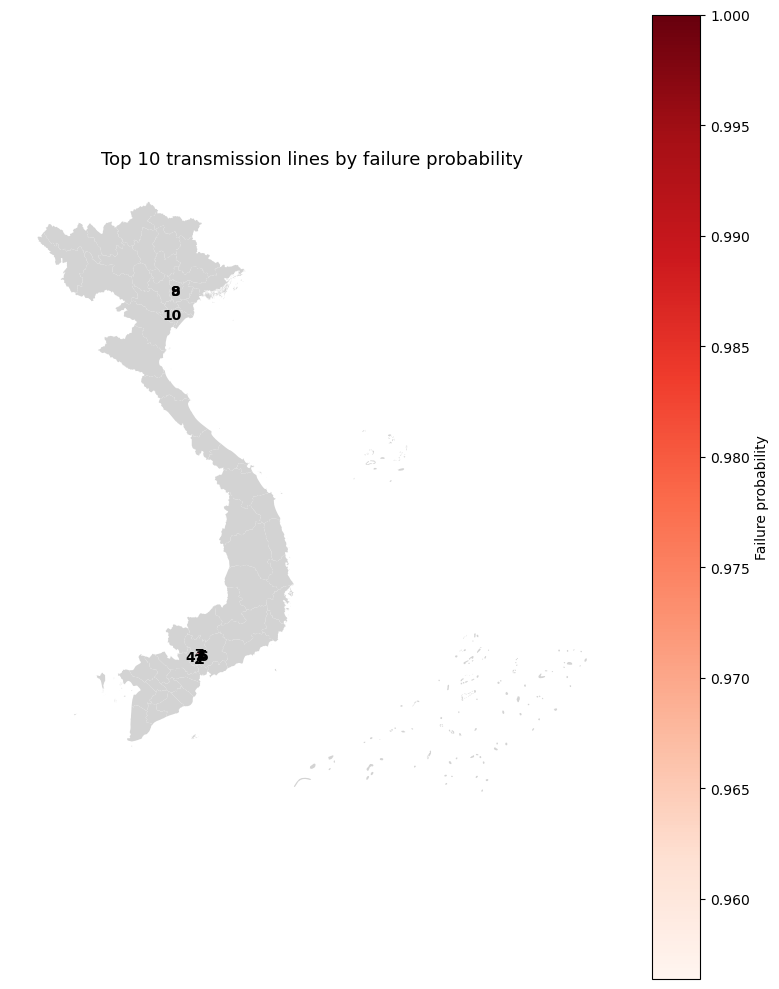

In [11]:
top10_lines = get_top10_overload_lines(
    lines_with_ratio=lines_gdf,
    output_dir=output_dir,
    prob_col="overload_prob"
)

plot_top10_overload_lines(
    gdf_top10=top10_lines,
    basemap=basemap,
    output_dir=output_dir
)


In [12]:
top10_lines

,LineID,Country,osm_id,fromNode,toNode,voltage,Length,std_type,apprent_power,max_i_ka,...,lon1_final,lat1_final,ID_node2_final,lon2_final,lat2_final,disconnected,geometry,overload_count,overload_prob,rank
0,LINEVN3216,VN,1204890304,NODEVN3669b,NODEVN3668,110.0,0.382623,490-AL1/64-ST1A 110.0,182.904565,0.96,...,692386.072689,1.197329e+06,1.204890e+09,692216.214501,1.197528e+06,no,"LINESTRING (106.75979 10.8263, 106.75964 10.82...",619.0,1.000000,1
1,LINEVN3218,VN,1204890399,NODEVN3668,NODEVN3670b,110.0,0.448371,490-AL1/64-ST1A 110.0,182.904565,0.96,...,692226.722489,1.197589e+06,1.204890e+09,692408.897164,1.197874e+06,no,"LINESTRING (106.75835 10.82866, 106.75849 10.8...",619.0,1.000000,2
2,LINEVN5686,VN,1361176528,NODEVN3665,NODEVN3212,110.0,2.498116,490-AL1/64-ST1A 110.0,182.904565,0.96,...,694563.799747,1.208598e+06,9.123000e+03,694613.598891,1.206652e+06,no,"LINESTRING (106.78031 10.92806, 106.7807 10.92...",619.0,1.000000,3
3,LINEVN4681,VN,1274599226,NODEVN2817,NODEVN2816,110.0,0.029596,490-AL1/64-ST1A 110.0,182.904565,0.96,...,665522.325630,1.203816e+06,7.424000e+03,665520.830551,1.203792e+06,no,"LINESTRING (106.51442 10.88626, 106.51441 10.8...",619.0,1.000000,4
4,LINEVN4712,VN,1274838475,NODEVN2828b,NODEVN3283a,110.0,0.237424,490-AL1/64-ST1A 110.0,182.904565,0.96,...,703973.199140,1.208575e+06,2.941273e+08,704042.292565,1.208389e+06,no,"LINESTRING (106.86637 10.92733, 106.86699 10.9...",619.0,1.000000,5
5,LINEVN3304,VN,1214445122,NODEVN3680,NODEVN3283a,110.0,0.404362,490-AL1/64-ST1A 110.0,182.904565,0.96,...,704558.729635,1.208314e+06,2.941273e+08,704369.655866,1.208275e+06,no,"LINESTRING (106.87171 10.92494, 106.87154 10.9...",619.0,1.000000,6
6,LINEVN3202,VN,1200729110,NODEVN3665,NODEVN3662a,110.0,8.991245,490-AL1/64-ST1A 110.0,182.904565,0.96,...,694540.439624,1.208601e+06,1.199781e+09,689731.592862,1.213007e+06,no,"LINESTRING (106.78009 10.92809, 106.78019 10.9...",619.0,1.000000,7
7,LINEVN0001b,VN,153608701,NODEVN3270a,NODEVN0001,110.0,2.692679,490-AL1/64-ST1A 110.0,182.904565,0.96,...,610714.852695,2.315181e+06,1.000000e+00,609979.512105,2.317122e+06,no,"LINESTRING (106.06478 20.93373, 106.06483 20.9...",609.0,0.983845,8
8,LINEVN0001a,VN,153608701,NODEVN3270a,NODEVN0001,110.0,2.692679,490-AL1/64-ST1A 110.0,182.904565,0.96,...,610714.852695,2.315181e+06,1.000000e+00,609979.512105,2.317122e+06,no,"LINESTRING (106.06478 20.93373, 106.06483 20.9...",609.0,0.983845,9
9,LINEVN2153,VN,1049657137,NODEVN1398,NODEVN1400,110.0,0.096000,490-AL1/64-ST1A 110.0,182.904565,0.96,...,602400.515071,2.242347e+06,2.415000e+03,602428.989525,2.242273e+06,no,"LINESTRING (105.98061 20.27618, 105.98088 20.2...",592.0,0.956381,10


✓ Saved: ../figures/20250725_hazard_iter_1000\combined_failure_maps_extended.png


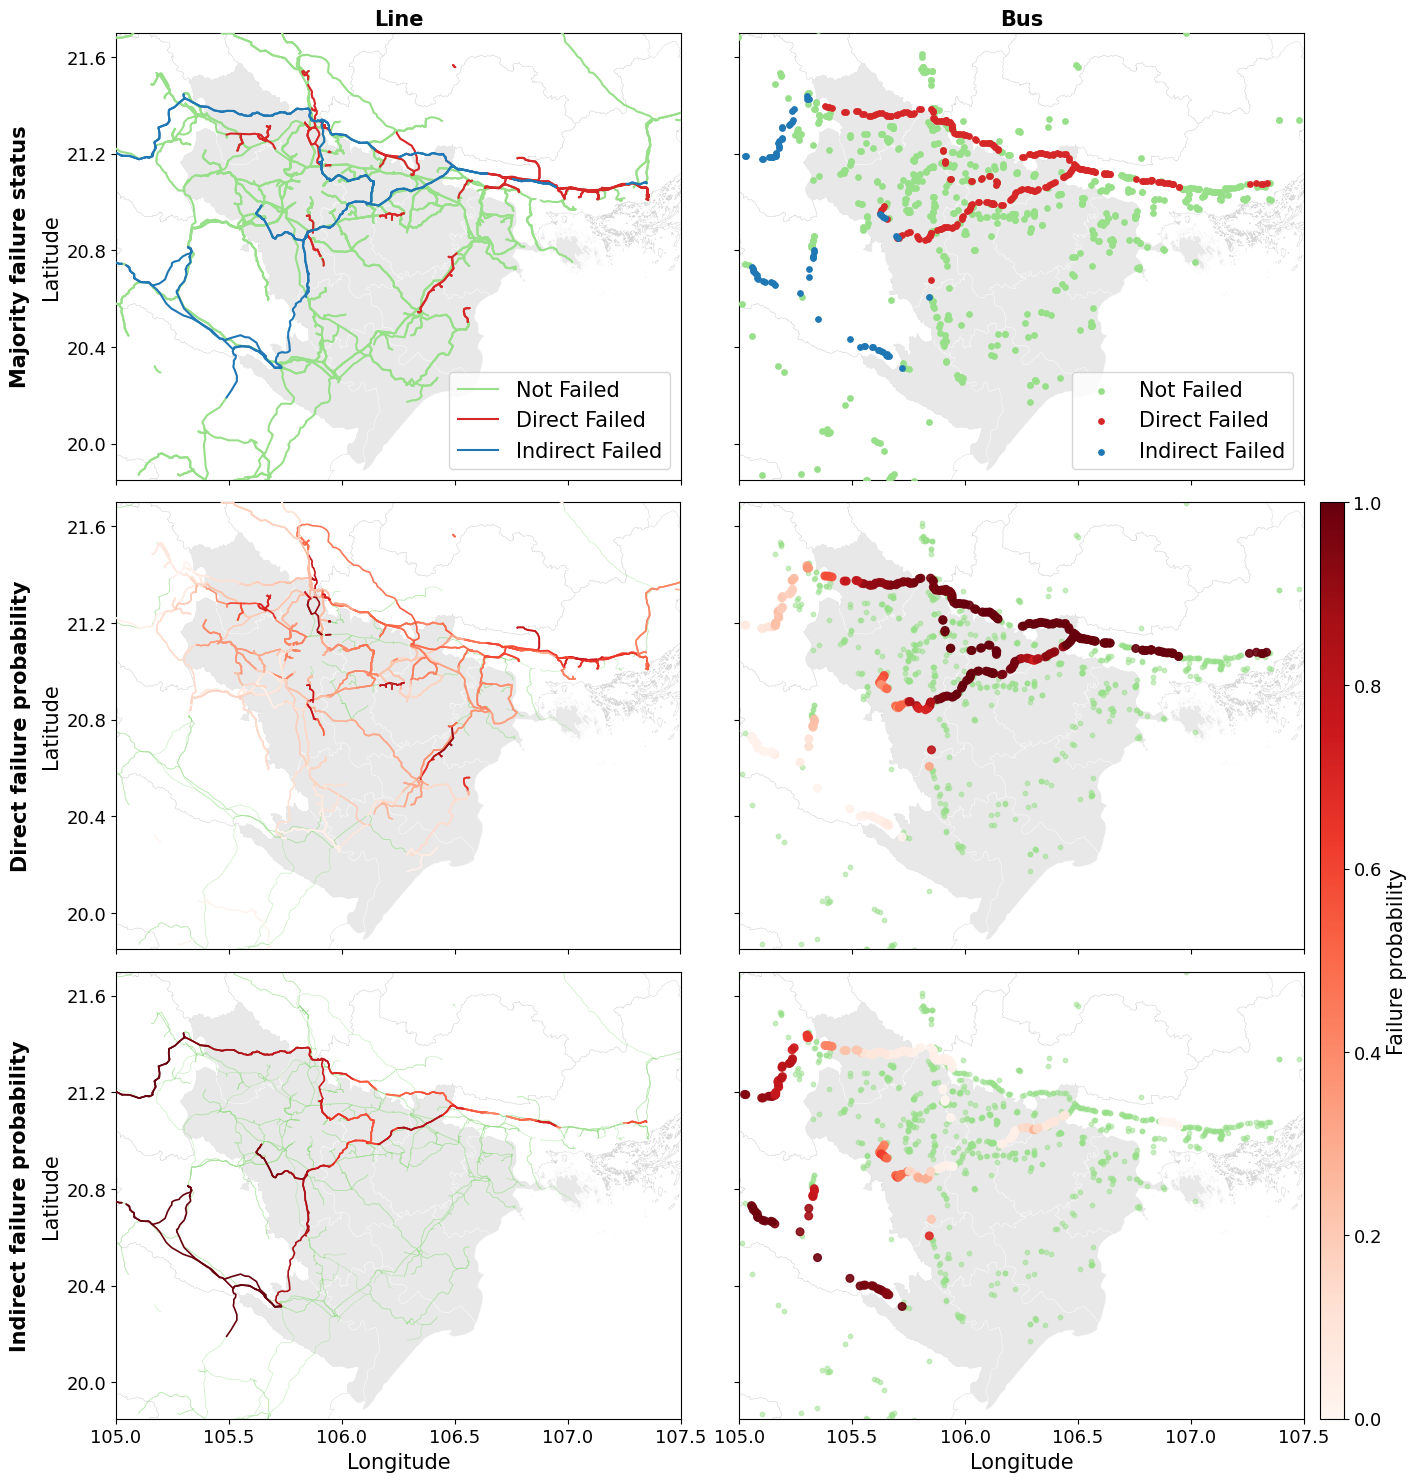

In [37]:
plot_combined_failure_maps_extended(lines_gdf_update, nodes_gdf_update, basemap, fig_path=output_dir)

In [25]:
def plot_overload_by_adm_ref_continous(lines_with_ratio, output_path=None, basemap=None):
    os.makedirs(output_path, exist_ok=True)

    lines_with_ratio = lines_with_ratio.to_crs("EPSG:4326")
    basemap = basemap.to_crs("EPSG:4326")

    pcode_list = ['VN106','VN111','VN101','VN107','VN103','VN109','VN113','VN117','VN115','VN104',
                  'VN717','VN711','VN707','VN713','VN701','VN709']
    target_regions = basemap[basemap["ADM1_PCODE"].isin(pcode_list)]
    other_regions = basemap[~basemap["ADM1_PCODE"].isin(pcode_list)]

    vmin = lines_with_ratio["overload_prob"].min()
    vmax = lines_with_ratio["overload_prob"].max()
    cmap = plt.colormaps.get_cmap("YlOrRd")
    norm = colors.Normalize(vmin=0.1, vmax=vmax)

    overloaded = lines_with_ratio[lines_with_ratio["overload_prob"] > 0]
    non_overloaded = lines_with_ratio[lines_with_ratio["overload_prob"] == 0]

    fig, ax = plt.subplots(1, 1, figsize=(8.5, 6))

    ax.set_xlabel("Longitude", fontsize=13)
    ax.set_ylabel("Latitude", fontsize=13)
    ax.set_xlim(105, 107.5)
    ax.set_ylim(19.85, 21.7)
    ax.set_aspect('auto')
    ax.tick_params(axis='both', labelsize=12)
    target_regions.plot(ax=ax, color='lightgray', edgecolor='white', linewidth=0.5, alpha=0.5, zorder=1)
    other_regions.plot(ax=ax, color='white', edgecolor='lightgray', linewidth=0.3, zorder=2)
    non_overloaded.plot(ax=ax, color='#98DF8A', linewidth=0.5, alpha=0.5, zorder=3, label='Not overloaded')
    overloaded.plot(ax=ax, column="overload_prob", cmap=cmap, norm=norm, linewidth=1.5, zorder=4)

    ax.set_aspect('auto')
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.legend(loc='lower right', fontsize=13)

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm._A = []
    cbar = fig.colorbar(sm, ax=ax, orientation="vertical", location='right', fraction=0.04, pad=0.01)
    cbar.set_label("Overload Ratio", fontsize=13)
    cbar.ax.tick_params(labelsize=12)

    plt.savefig(os.path.join(output_path, "overload_map_region_split_continous.png"), dpi=600, bbox_inches="tight")

    return overloaded

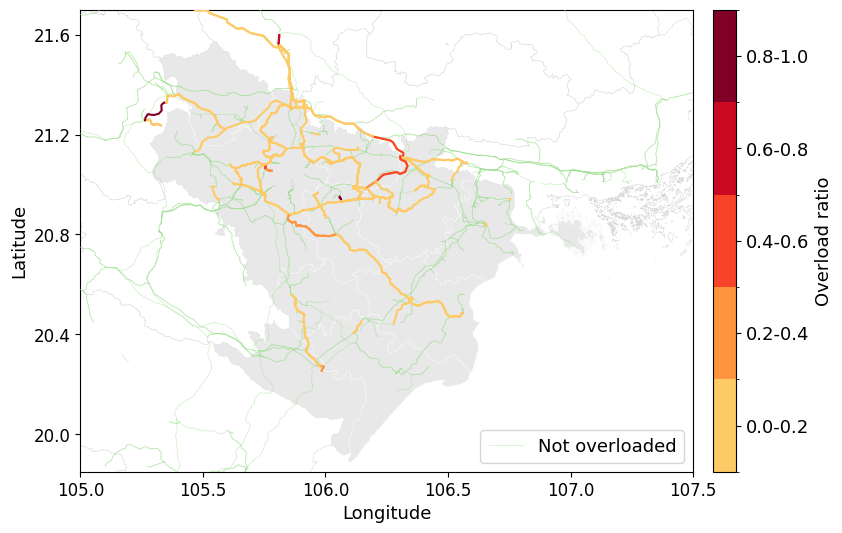

In [38]:
plot_overload_by_adm_ref_fixed_bins(lines_gdf, output_path=output_dir, basemap=basemap)

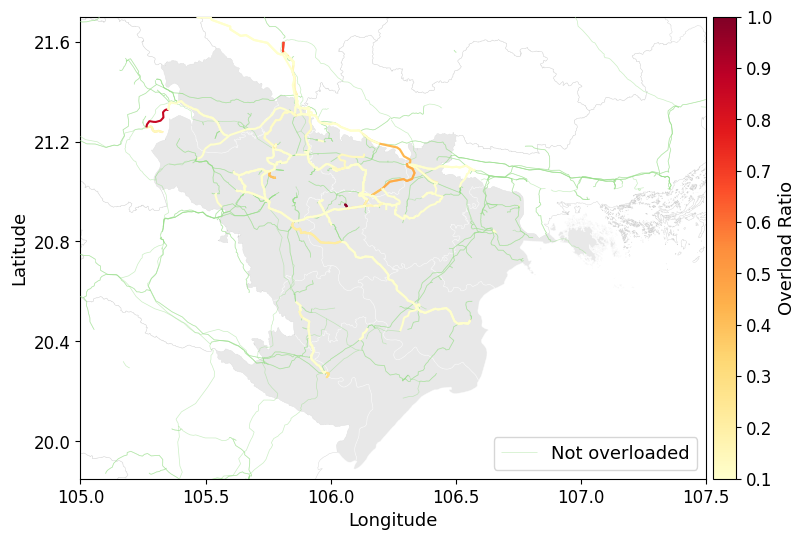

In [ ]:
overload_lines = plot_overload_by_adm_ref_continous(lines_gdf, output_path=output_dir, basemap=basemap)

In [33]:
# === Quantitative analysis of overloaded lines ===
total_lines = len(lines_gdf)
overloaded_count = len(overload_lines)
overloaded_ratio = overloaded_count / total_lines * 100

print(f"Total lines: {total_lines}")
print(f"Overloaded lines: {overloaded_count} ({overloaded_ratio:.2f}%)")
print(f"Overload probability - mean: {overload_lines['overload_prob'].mean():.3f}, "
        f"median: {overload_lines['overload_prob'].median():.3f}, "
        f"max: {overload_lines['overload_prob'].max():.3f}")

# Top 10 overloaded lines
print("\nTop 10 lines by overload probability:")
print(overload_lines[['LineID', 'overload_prob']].sort_values(
    'overload_prob', ascending=False).head(20))

# Stats by province if ADM1_PCODE exists
if 'ADM1_PCODE' in overload_lines.columns:
    province_stats = (
        overload_lines.groupby('ADM1_PCODE')['overload_prob']
        .agg(['count', 'mean', 'max'])
        .sort_values('mean', ascending=False)
    )
    print("\nOverload stats by province:")
    print(province_stats)


Total lines: 6799
Overloaded lines: 391 (5.75%)
Overload probability - mean: 0.086, median: 0.024, max: 1.000

Top 10 lines by overload probability:
           LineID  overload_prob
6704   LINEVN5686       1.000000
5953   LINEVN4712       1.000000
5900   LINEVN4681       1.000000
4236   LINEVN3304       1.000000
4115   LINEVN3218       1.000000
4112   LINEVN3216       1.000000
4100   LINEVN3202       1.000000
1     LINEVN0001b       0.983845
0     LINEVN0001a       0.983845
2901   LINEVN2153       0.956381
5048   LINEVN4010       0.856220
4771  LINEVN3832a       0.768982
4772  LINEVN3832b       0.673667
4940  LINEVN3944a       0.513732
1524  LINEVN1154b       0.463651
1172  LINEVN0900b       0.426494
4946  LINEVN3947a       0.415186
4947  LINEVN3947b       0.410339
4959  LINEVN3956b       0.408724
4944  LINEVN3946a       0.408724

Overload stats by province:
            count      mean       max
ADM1_PCODE                           
VN801           1  1.000000  1.000000
VN701          

In [19]:
def plot_load_failure_probability(load_status_df, loads_gdf, results_df, basemap, output_path=None):
    # === Ensure ID formats match ===
    # loads_gdf["osmid"] = pd.to_numeric(loads_gdf["osmid"], errors="coerce").astype("Int64")
    # load_status_df["load_id"] = pd.to_numeric(load_status_df["load_id"], errors="coerce").astype("Int64")

    # === Filter out iterations with failed powerflow ===
    successful_iters = results_df.loc[results_df["powerflow_success"], "fail_iter"]
    load_status_df = load_status_df[load_status_df["fail_iter"].isin(successful_iters)]

    # === Calculate failure probability ===
    failure_stats = (
        load_status_df.groupby("load_id")["served"]
        .mean()
        .reset_index(name="served_ratio")
    )
    failure_stats["failure_probability"] = 1 - failure_stats["served_ratio"]

    # === Merge & fill missing with 0 ===
    loads_gdf = loads_gdf.merge(failure_stats[["load_id", "failure_probability", "served_ratio"]],
                                left_on="osmid", right_on="load_id", how="left")
    loads_gdf["failure_probability"] = loads_gdf["failure_probability"].fillna(0)

    # === Basemap preprocessing ===
    loads_gdf = loads_gdf.to_crs("EPSG:4326")
    basemap = basemap.to_crs("EPSG:4326")

    pcode_list = ['VN106','VN111','VN101','VN107','VN103','VN109','VN113','VN117','VN115','VN104']
    target_regions = basemap[basemap["ADM1_PCODE"].isin(pcode_list)]
    other_regions = basemap[~basemap["ADM1_PCODE"].isin(pcode_list)]

    # === Split data ===
    always_served_loads = loads_gdf[loads_gdf["failure_probability"] == 0]
    failed_loads = loads_gdf[loads_gdf["failure_probability"] > 0]

    # === Colormap ===
    cmap = cm.YlOrRd
    norm = colors.Normalize(vmin=0, vmax=1)

    # === Plot ===
    fig, ax = plt.subplots(1, 1, figsize=(8.5, 6))

    # ax.set_title("Load Failure Probability", fontsize=15)
    ax.set_xlim(105, 107.5)
    ax.set_ylim(19.85, 21.7)
    ax.set_xlabel("Longitude", fontsize=13)
    ax.set_ylabel("Latitude", fontsize=13)
    ax.tick_params(axis='both', labelsize=12)

    # Basemap
    target_regions.plot(ax=ax, color='lightgray', edgecolor='white', linewidth=0.5, zorder=1)
    other_regions.plot(ax=ax, color='white', edgecolor='lightgray', linewidth=0.3, zorder=0)

    # Plot zero-failure loads (fixed color)
    always_served_loads.plot(ax=ax, color='green', markersize=10, label="Failure p = 0", zorder=2)

    # # Plot partial failures (gradient color)
    failed_loads.plot(ax=ax, column="failure_probability", cmap=cmap, norm=norm, zorder=3)
    # loads_gdf.plot(ax=ax, column="failure_probability", cmap=cmap, norm=norm, zorder=3)

    # Colorbar for only failed loads
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm._A = []
    cbar = fig.colorbar(sm, ax=ax, orientation="vertical", fraction=0.04, pad=0.02)
    cbar.set_label("Failure probability", fontsize=13)
    cbar.ax.tick_params(labelsize=12)

    # ax.legend(loc='lower right', fontsize=13)
    # Manually create legend for green loads
    legend_elements = [
        Patch(facecolor='green', label='Failure p = 0')
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=13)

    if output_path:
        plt.savefig(os.path.join(output_path, "load_failure_probability.png"), dpi=600, bbox_inches="tight")
        print(f"✓ Saved to {output_path}")

    return loads_gdf, failed_loads

✓ Saved to ../figures/20250725_hazard_iter_1000


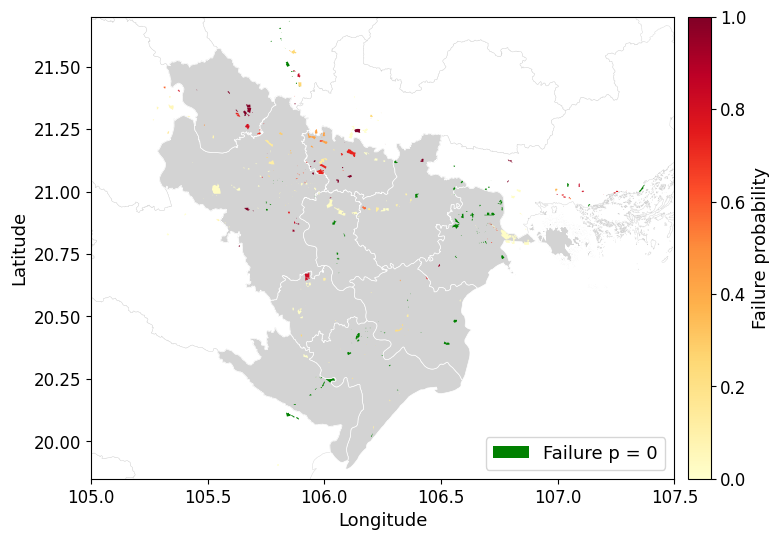

In [20]:
loads_gdf_update, failed_loads = plot_load_failure_probability(load_status_df, loads_gdf, results_df, basemap=basemap, output_path=output_dir)

In [32]:
# === Quantitative analysis of failed loads ===
total_loads = len(loads_gdf)
failed_count = len(failed_loads)
failed_ratio = failed_count / total_loads * 100

print(f"Total loads: {total_loads}")
print(f"Failed loads: {failed_count} ({failed_ratio:.2f}%)")
print(f"Failure probability - mean: {failed_loads['failure_probability'].mean():.3f}, "
      f"median: {failed_loads['failure_probability'].median():.3f}, "
      f"max: {failed_loads['failure_probability'].max():.3f}")

# Top 10 failed loads
print("\nTop 10 loads by failure probability:")
print(failed_loads[['osmid', 'failure_probability', 'served_ratio']].sort_values(
    'failure_probability', ascending=False).head(100))

# If province info exists in loads_gdf
if 'province' in loads_gdf.columns:
    province_stats = (
        failed_loads.groupby('province')['failure_probability']
        .agg(['count', 'mean', 'max'])
        .sort_values('mean', ascending=False)
    )
    print("\nFailure stats by province:")
    print(province_stats)


Total loads: 1378
Failed loads: 358 (25.98%)
Failure probability - mean: 0.318, median: 0.101, max: 1.000

Top 10 loads by failure probability:
           osmid  failure_probability  served_ratio
1279   875944784             1.000000      0.000000
1274  1119170923             1.000000      0.000000
920    210752755             1.000000      0.000000
1251   708617214             1.000000      0.000000
1252   708617216             1.000000      0.000000
1291   704069818             1.000000      0.000000
1346   596051637             1.000000      0.000000
1257   875944834             1.000000      0.000000
1021   593793800             1.000000      0.000000
1275  1119170920             1.000000      0.000000
1193   659860835             1.000000      0.000000
1302   875641765             1.000000      0.000000
1332   596051687             1.000000      0.000000
1333   595824021             1.000000      0.000000
1301   549956792             1.000000      0.000000
1282   642268658        

In [41]:
load_ratio_df = prepare_loads_map(load_status_df, loads_gdf)

In [11]:
load_ratio_df.head()

,element_type,osmid,nodes,landuse,name,name:en,operator,owner,plant:method,plant:output:electricity,plant:source,power,wikidata,source,industrial,access,barrier,amenity,parking,access:conditional,building:levels,fence,material,addr:housenumber,addr:street,addr:street:en,addr:street:zh,building,bus,depot,name:zh,operator:type,ownership,ref,alt_name,building:part,building:part:levels,layer,official_name,official_name:en,official_name:zh,old_name,old_name:en,old_name:zh,government,motor_vehicle,operation,operator:en,operator:ownership,operator:wikidata,operator:zh,fence:material,fuel,man_made,measurement,pipeline,pumping_station,substance,substation,usage,addr:housename,addr:housename:en,addr:housename:zh,area,drinking_water,note:landuse,salt,utility,office,addr:suburb,addr:suburb:en,addr:suburb:zh,phone,website,reservoir:location,telecom,addr:borough,addr:borough:en,addr:borough:zh,temporary,cargo,designation,designation:en,designation:short_name,designation:short_name:en,designation:zh,port,short_name,short_name:en,was:landuse,ways,type,waste,wall,natural,brand,brand:en,brand:zh,demolished:amenity,demolished:end_date,demolished:name,demolished:name:en,demolished:name:zh,depot:service,network,network:en,network:zh,owner:en,owner:wikidata,owner:zh,proposed:landuse,hazard,was:end_date,was:name,was:name:en,was:name:zh,pumping_station:area,fire_station:type,product,product:wikidata,alt_name:en,alt_name:zh,fixme,fixme:name,fixme:name:en,fixme:name:zh,addr:city,wikipedia,operator:zh-Hans,operator:zh-Hant,brand:wikidata,not:amenity,police,addr:street:carriageway_ref:kmb,addr:street:direction:kmb,addr:street:ref:kmb,addr:street:wikidata,plant:output:cold_water,pipeline:inspection_gauge,addr:town,addr:town:en,addr:town:zh,description,industry,operator:short,operator:short:en,operator:short:zh,operator:short:zh-Hans,operator:short:zh-Hant,opened,name:zh-Hans,name:zh-Hant,not:man_made,water,owner:official_name,owner:official_name:zh,owner:official_name:zh-Hans,owner:official_name:zh-Hant,owner:ref,owner:short_name,owner:short_name:en,owner:short_name:zh,name:de,name:fr,name:nan,name:nan-HJ,name:nan-POJ,name:nan-TL,start_date,addr:country,addr:full,addr:place,addr:postcode,addr:province,not:substance,not:substance:wikidata,closing_date,description:en,description:zh,proposed:leisure,addr:district,proposed:amenity,proposed:description,proposed:description:en,proposed:description:zh,branch,branch:en,branch:zh,education,addr:town:wikidata,brand:zh-Hans,brand:zh-Hant,owner:zh-Hans,owner:zh-Hant,recycling_type,demolished:landcover,demolished:natural,operator:short_name,operator:short_name:en,operator:short_name:zh,short_name:zh,addr:city_block,addr:city_block:en,addr:city_block:zh,noname:zh,not:landuse,waterway,check_date,construction,demolished:anthropogenic,note,was:amenity,alt_name_1,fax,email,smoking,access:start_date,was:access,was:access:end_date,service,loc_name,loc_name:en,reg_name,reg_name:en,reg_name:zh,tourism,was:leisure,roof:levels,roof:shape,addr:quarter,addr:quarter:en,addr:quarter:zh,wastewater_plant,frequency,voltage,height,wikimedia_commons,fuel:JetA1,not:aeroway,name:yue,note:highway,mooring,brand:wikipedia,boundary,wall:height,int_name,name:zh_pinyin,abutters,commercial,retail,college,sewerage,content,demolished:water,demolished:source,was:parking,name:yue-Hant,location,plant:output:hot_water,fence_type,addr:plot,addr:plot:en,addr:plot:zh,proposed:demolished:landuse,proposed:demolished:man_made,proposed:residential,healthcare,operator:official_name,operator:official_name:en,operator:official_name:zh,operator:ref,demolished:landuse,disputed,informal,operator:owner,operator:owner:zh,drinking_water:access,addr:place:en,addr:place:zh,brand:ref,network:ref,network:wikidata,subway,hgv_articulated,trailer,addr:plot:loc_ref,proposed:name,proposed:name:en,proposed:name:zh,seamark:harbour:category,operator:wikipedia,website:en,website:zh,demolished:maintained,demolished:managed,fixme:highway,fixme:sport,loc_name:zh,residential,opening_d

In [52]:
def analyze_load_served_ratio_by_adm(load_ratio_df, loads_gdf, results_df, output_dir):
    successful_iters = results_df.loc[results_df["powerflow_success"], "fail_iter"]
    load_ratio_df = load_ratio_df[load_ratio_df["fail_iter"].isin(successful_iters)]

    df_failed = load_ratio_df[load_ratio_df["served_ratio_mean"] < 1]
    adm_with_failures = df_failed["ADM1_EN"].unique()
    df_all = load_ratio_df[load_ratio_df["ADM1_EN"].isin(adm_with_failures)]
    avg_served = df_all.groupby("osmid")["served_ratio_mean"].mean().rename("served_ratio")

    loads_gdf = loads_gdf.copy()
    loads_gdf["served_ratio"] = loads_gdf["osmid"].map(avg_served)
    filtered = loads_gdf.dropna(subset=["ADM1_EN", "served_ratio"])
    print(filtered.groupby("ADM1_EN")["served_ratio"].count().sort_values())

    median_order = (
        filtered.groupby("ADM1_EN")["served_ratio"]
        .median()
        .sort_values(ascending=True)
        .reset_index()
        .rename(columns={"served_ratio": "served_ratio_median"})
    )
    median_order_list = median_order["ADM1_EN"].astype(str).tolist()
    counts = filtered["ADM1_EN"].value_counts().reindex(median_order_list).fillna(0)

    # Calculate standard deviation per ADM1_EN
    std_dev = filtered.groupby("ADM1_EN")["served_ratio"].std().reset_index(name="served_ratio_std")
    merged_stats = pd.merge(median_order, std_dev, on="ADM1_EN")

    # Identify top 5 unstable and stable provinces
    df_unstable = merged_stats.sort_values(by="served_ratio_std", ascending=False).head(3)
    df_stable = merged_stats.sort_values(by="served_ratio_std", ascending=True).head(3)
    fig, ax1 = plt.subplots(figsize=(14, 6))

    # Boxplot
    sns.boxplot(
        data=filtered,
        x="ADM1_EN",
        y="served_ratio",
        order=median_order_list,
        ax=ax1,
        color="skyblue"
    )

    # 均值 + CI
    # means = filtered.groupby("ADM1_EN")["served_ratio"].mean()
    # for xtick, adm1 in enumerate(median_order_list):
    #     group = filtered[filtered["ADM1_EN"] == adm1]["served_ratio"].values
    #     if len(group) > 1:
    #         ci = bootstrap((group,), np.mean, confidence_level=0.95, n_resamples=1000, method="basic")
    #         ci_low, ci_high = ci.confidence_interval
    #         ax1.plot(xtick, means[adm1], 'ro')  # mean
    #         ax1.vlines(xtick, ci_low, ci_high, color='#8C564B', linewidth=1.2)
    #     else:
    #         ax1.plot(xtick, means[adm1], 'ro')

    # 平均线
    # ax1.axhline(filtered["served_ratio"].mean(), color="green", linestyle="--", linewidth=1.2, label="Global Mean")
    ax1.set_ylabel("Served ratio", fontsize=13)
    ax1.set_xlabel("Provinces (sorted by median served ratio)", fontsize=13)
    ax1.set_xticklabels(median_order_list, rotation=45, ha="right")
    ax1.tick_params(axis='x', labelsize=10)
    ax1.grid(axis="y", linestyle="--", alpha=0.4)

    # Color xtick labels for stable/unstable
    xtick_labels = ax1.get_xticklabels()
    for label in xtick_labels:
        adm = label.get_text()
        if adm in df_unstable["ADM1_EN"].values:
            label.set_fontweight("bold")
        elif adm in df_stable["ADM1_EN"].values:
            label.set_color("#2CA02C")  # green

    # === 右侧 y 轴 ===
    # ax2 = ax1.twinx()
    # ax2.bar(median_order_list, counts.values, alpha=0.25, color="gray", label="Load count")
    # ax2.set_ylabel("Load count", fontsize=13)
    # # ax2.legend(loc="upper right", fontsize=13)
    # ax2.legend(loc='center right', bbox_to_anchor=(1, 0.25), fontsize=13)

    plt.title("Loads served ratio distribution by province (Typhoon Yagi)", fontsize=13)
    plt.tight_layout()
    # os.makedirs(output_dir, exist_ok=True)
    plt.savefig(os.path.join(output_dir, "load_served_ratio_boxplot_by_adm1_count.png"), dpi=400)

    return filtered, median_order, std_dev, df_unstable, df_stable

ADM1_EN
Tuyen Quang         1
Hoa Binh            4
Bac Giang          16
Vinh Phuc          16
Ha Nam             16
Thanh Hoa          18
Hung Yen           21
Ninh Binh          22
Thai Binh          23
Phu Tho            24
Thai Nguyen        25
Hai Duong          27
Nam Dinh           29
Bac Ninh           30
Quang Ninh         34
Hai Phong city     84
Ha Noi            120
Name: served_ratio, dtype: int64


C:\Users\mye500\AppData\Local\Temp\ipykernel_33392\3661792505.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(median_order_list, rotation=45, ha="right")


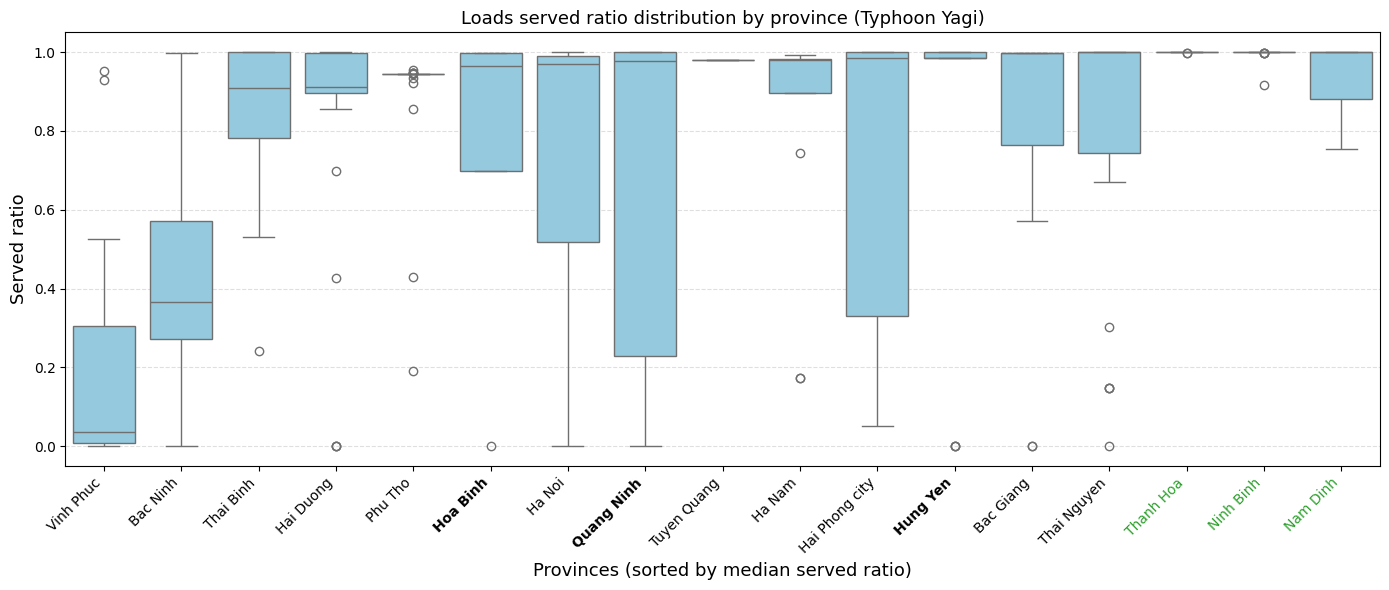

In [53]:
loads_gdf_filtered, median_order, std_dev, df_unstable, df_stable = analyze_load_served_ratio_by_adm(load_ratio_df, loads_gdf, results_df, output_dir)

In [48]:
median_order

,ADM1_EN,served_ratio_median
0,Vinh Phuc,0.035541
1,Bac Ninh,0.365105
2,Thai Binh,0.907916
3,Hai Duong,0.911147
4,Phu Tho,0.943457
5,Hoa Binh,0.964459
6,Ha Noi,0.970921
7,Quang Ninh,0.977383
8,Tuyen Quang,0.978998
9,Ha Nam,0.980614


In [49]:
std_dev

,ADM1_EN,served_ratio_std
0,Bac Giang,0.338921
1,Bac Ninh,0.318608
2,Ha Nam,0.272407
3,Ha Noi,0.328001
4,Hai Duong,0.317282
5,Hai Phong city,0.304230
6,Hoa Binh,0.488858
7,Hung Yen,0.355755
8,Nam Dinh,0.081966
9,Ninh Binh,0.017856


In [51]:
df_unstable.to_csv(os.path.join(base_dir, "df_unstable.csv"))
df_stable.to_csv(os.path.join(base_dir, "df_stable.csv"))
median_order.to_csv(os.path.join(base_dir, "median_order.csv"))
std_dev.to_csv(os.path.join(base_dir, "std_dev.csv"))

# OLD VERSION

In [ ]:
# def plot_direct_indirect_failure_probability_updated(lines_gdf, nodes_gdf, basemap, fig_path=None):
#     # Ensure correct CRS
#     lines_gdf.set_crs("EPSG:4326", inplace=True)
#     nodes_gdf.set_crs("EPSG:4326", inplace=True)
#     basemap.set_crs("EPSG:4326", inplace=True)

#     # 区域划分
#     pcode_list = ['VN106','VN111','VN101','VN107','VN103','VN109','VN113','VN117','VN115','VN104']
#     target_regions = basemap[basemap["ADM1_PCODE"].isin(pcode_list)]
#     other_regions = basemap[~basemap["ADM1_PCODE"].isin(pcode_list)]

#     cmap = cm.Reds
#     norm = colors.Normalize(vmin=0, vmax=1)

#     fig, axes = plt.subplots(2, 2, figsize=(16, 12), constrained_layout=True)

#     titles = [
#         "Line direct failure probability", "Bus direct failure probability",
#         "Line indirect failure probability", "Bus indirect failure probability"
#     ]
#     col_pairs = [
#         (lines_gdf, 'p_direct'), (nodes_gdf, 'p_direct'),
#         (lines_gdf, 'p_indirect'), (nodes_gdf, 'p_indirect')
#     ]

#     for ax, title, (gdf, col) in zip(axes.flat, titles, col_pairs):
#         # 底图
#         target_regions.plot(ax=ax, color='lightgray', edgecolor='white', linewidth=0.8, alpha=0.5, zorder=1)
#         other_regions.plot(ax=ax, color='white', edgecolor='lightgray', linewidth=0.5, zorder=0)

#         # 绘制失败概率
#         if gdf.geometry.iloc[0].geom_type == 'Point':
#             gdf[gdf[col] == 0].plot(ax=ax, color='#98DF8A', markersize=10, alpha=0.5, zorder=2)
#             gdf[gdf[col] > 0].plot(ax=ax, column=col, cmap=cmap, norm=norm,
#                                    markersize=30, alpha=0.9, zorder=3)
#         else:
#             gdf[gdf[col] == 0].plot(ax=ax, color='#98DF8A', linewidth=0.5, alpha=0.5, zorder=2)
#             gdf[gdf[col] > 0].plot(ax=ax, column=col, cmap=cmap, norm=norm,
#                                    linewidth=1.5, zorder=3)

#         # 坐标和标题设置
#         ax.set_title(title, fontsize=16)
#         ax.set_xlim(105, 107.5)
#         ax.set_ylim(19.85, 21.7)
#         ax.set_xlabel("Longitude", fontsize=14)
#         if 'Bus' in title:
#             ax.tick_params(labelleft=False)
#         else:
#             ax.set_ylabel("Latitude", fontsize=14)
#         ax.tick_params(axis='both', which='major', labelsize=13)
#         ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
#         ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
#         ax.set_aspect('auto')


#     # 单一 colorbar
#     sm = cm.ScalarMappable(cmap=cmap, norm=norm)
#     sm._A = []
#     cbar = fig.colorbar(sm, ax=axes[:, 1], orientation="vertical", fraction=0.04)
#     cbar.set_label("Failure probability", fontsize=16)
#     cbar.ax.tick_params(labelsize=13)

#     # 保存或显示
#     if fig_path:
#         os.makedirs(fig_path, exist_ok=True)
#         output_file = os.path.join(fig_path, "direct_indirect_failure_probabilities.png")
#         plt.savefig(output_file, dpi=600, bbox_inches="tight")
#         print(f"✓ Saved: {output_file}")
#     else:
#         plt.show()


In [12]:
# plot_direct_indirect_failure_probability_updated(lines_gdf_update, nodes_gdf_update, basemap, fig_path=output_path)

In [ ]:
# def plot_majority_failure_status_map(lines_gdf, nodes_gdf, basemap, fig_path):
#     """
#     Plot majority failure status (most frequent among iterations) for lines and buses,
#     using the same left-right map layout.
#     """
#     lines_gdf = lines_gdf.to_crs("EPSG:4326")
#     nodes_gdf = nodes_gdf.to_crs("EPSG:4326")
#     basemap = basemap.to_crs("EPSG:4326")

#     # Define region masks
#     pcode_list = ['VN106','VN111','VN101','VN107','VN103','VN109','VN113','VN117','VN115','VN104']
#     target_regions = basemap[basemap["ADM1_PCODE"].isin(pcode_list)]
#     other_regions = basemap[~basemap["ADM1_PCODE"].isin(pcode_list)]

#     # Status colors (colorblind-friendly)
#     status_colors = {
#         'Not Failed': '#98DF8A',
#         'Direct Failed': '#D62728',
#         'Indirect Failed': '#1F77B4'
#     }

#     def compute_majority_status(gdf):
#         impact_cols = [col for col in gdf.columns if col.startswith("impact_")]
#         majority_status = gdf[impact_cols].mode(axis=1)[0]
#         gdf['majority_status'] = majority_status
#         return gdf

#     # Compute majority status
#     lines_gdf = compute_majority_status(lines_gdf)
#     nodes_gdf = compute_majority_status(nodes_gdf)

#     # Plot
#     fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
#     titles = ["Line majority failure status", "Bus majority failure status"]

#     for ax, gdf, title in zip(axes, [lines_gdf, nodes_gdf], titles):
#         # Plot base map
#         target_regions.plot(ax=ax, color='lightgray', edgecolor='white', linewidth=0.5, alpha=0.5, zorder=1)
#         other_regions.plot(ax=ax, color='white', edgecolor='lightgray', linewidth=0.3, zorder=0)

#         # Plot each status
#         for status, color in status_colors.items():
#             subset = gdf[gdf['majority_status'] == status]
#             if subset.empty:
#                 continue
#             if subset.geometry.iloc[0].geom_type == 'Point':
#                 subset.plot(ax=ax, color=color, markersize=15, label=status, zorder=3)
#             else:
#                 subset.plot(ax=ax, color=color, linewidth=1.5, label=status, zorder=3)

#         # Format
#         ax.set_title(title, fontsize=15)
#         ax.set_xlim(105, 107.5)
#         ax.set_ylim(19.85, 21.7)
#         ax.set_xlabel("Longitude", fontsize=14)
#         if "Line" in title:
#             ax.set_ylabel("Latitude", fontsize=14)
#         else:
#             ax.tick_params(labelleft=False)
#         ax.tick_params(axis='both', which='major', labelsize=13)
#         ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
#         ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
#         ax.legend(loc='lower right', fontsize=13)

#     # Save or show
#     if fig_path:
#         os.makedirs(fig_path, exist_ok=True)
#         out_file = os.path.join(fig_path, "majority_failure_status_map.png")
#         plt.savefig(out_file, dpi=600, bbox_inches="tight")
#         print(f"✓ Saved: {out_file}")
#     else:
#         plt.show()


✓ Saved: ../figures/20250725_hazard_iter_5\majority_failure_status_map.png


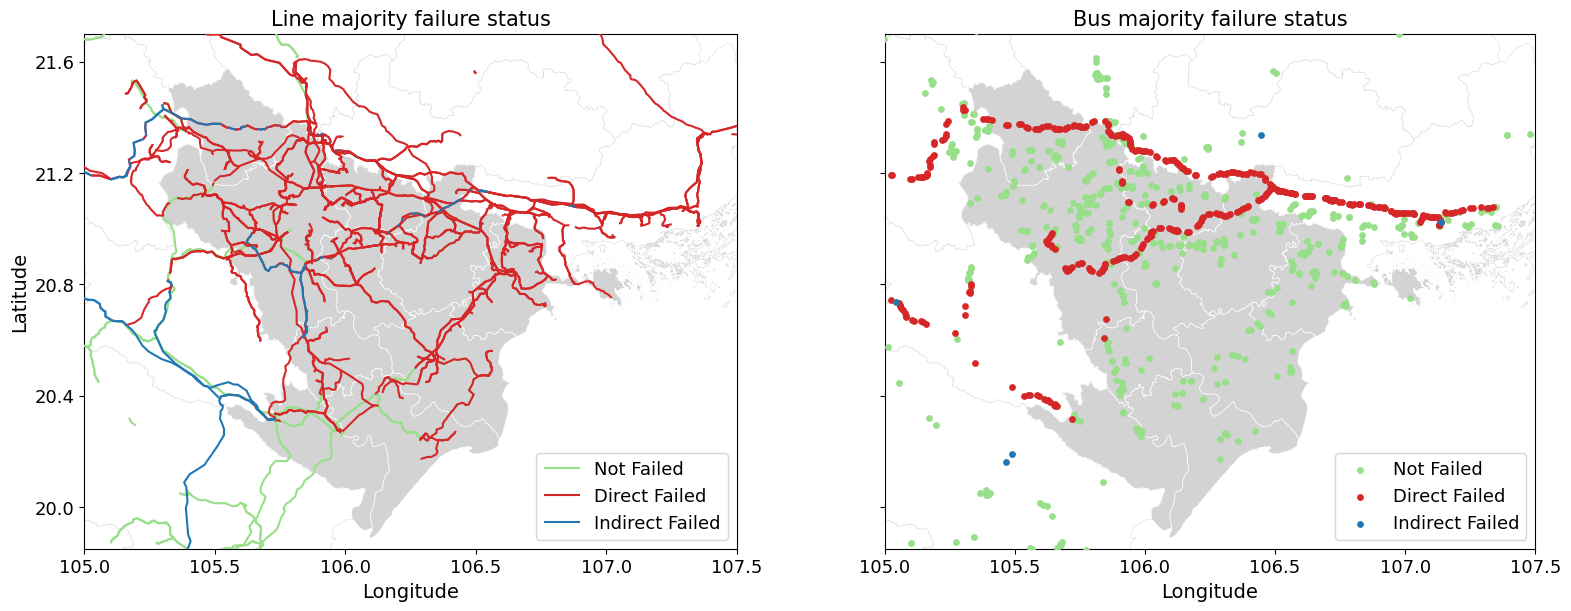

In [ ]:
# plot_majority_failure_status_map(lines_gdf_update, nodes_gdf_update, basemap, fig_path=output_path)

In [ ]:
# def analyze_overloaded_lines(overloaded_lines_df, lines_gdf, threshold = 0.5, output_path=None):
#     os.makedirs(output_path, exist_ok=True)
    
#     # === Step 1: 统计每条线路超载次数 ===
#     overload_count = overloaded_lines_df.groupby("line_name").size().rename("overload_count").reset_index()
    
#     # 从 overloaded_lines_df 提取所有唯一的仿真组合
#     sim_combinations = overloaded_lines_df["fail_iter"].drop_duplicates()
#     # 真实参与仿真的总次数（成功且线路有结果）
#     num_simulations = sim_combinations.shape[0]

#     overload_count["overload_prob"] = overload_count["overload_count"] / num_simulations
#     overload_count = overload_count.sort_values("overload_prob", ascending=False)

#     # 保存统计表
#     overload_count.to_csv(os.path.join(output_path, "overloaded_line_stats.csv"))

#     # === Step 2: 关键线路筛选 ===
#     critical_lines = overload_count[overload_count["overload_prob"] >= threshold]
#     critical_lines.to_csv(os.path.join(output_path, f"critical_lines_over_{int(threshold*100)}pct.csv"))

#     # === Step 3a: 可视化柱状图 ===
#     plt.figure(figsize=(8, 6))
#     top_lines = overload_count.head(10)
#     plt.bar(top_lines["line_name"], top_lines["overload_prob"], color="tomato")
#     plt.ylabel("Overload frequency")
#     plt.xlabel("LineID (Top 10)")
#     plt.title("Top 10 line overload ratios")
#     plt.tight_layout()
#     plt.savefig(os.path.join(output_path, "overload_bar_top10.png"), dpi=300)
#     plt.show()
#     plt.close()

#     # === Step 3b: 地图可视化 ===
#     lines_with_ratio = lines_gdf.merge(overload_count, how="left", left_on="LineID", right_on="line_name")
#     lines_with_ratio["overload_prob"] = lines_with_ratio["overload_prob"].fillna(0)

#     fig, ax = plt.subplots(1, 1, figsize=(12, 10))
#     lines_with_ratio.plot(column="overload_prob", cmap="Reds", legend=True,
#                           linewidth=1, ax=ax)
#     ax.set_title("Line overload frequency map", fontsize=15)
#     plt.axis("off")
#     plt.savefig(os.path.join(output_path, "overload_map.png"), dpi=300)
#     plt.show()
#     plt.close()

#     # === Step 4: 过载率 vs 线路长度 ===
#     if "Length" in lines_with_ratio.columns:
#         plt.figure(figsize=(8, 6))
#         plt.scatter(lines_with_ratio["Length"], lines_with_ratio["overload_prob"], alpha=0.6)
#         plt.xlabel("Line Length (km)")
#         plt.ylabel("Overload Ratio")
#         plt.title("Overload Ratio vs. Line Length")
#         plt.grid(True)
#         plt.tight_layout()
#         plt.savefig(os.path.join(output_path, "overload_vs_length.png"), dpi=300)
#         plt.show()

#     # === Step 5: 区域统计（如有）===
#     region_field = "ADM1_EN" if "ADM1_EN" in lines_with_ratio.columns else None
#     if region_field:
#         region_critical = lines_with_ratio[lines_with_ratio["overload_prob"] >= threshold]
#         region_summary = region_critical.groupby(region_field).size().rename("critical_line_count").reset_index()
#         region_summary.to_csv(os.path.join(output_path, "critical_line_count_by_region.csv"), index=False)

#     # === Step 6: Histogram of overload ratio bins (vs. total lines) ===
#     bins = np.arange(0.01, 1.01, 0.1)
#     lines_with_ratio["overload_prob"] = lines_with_ratio["overload_prob"].fillna(0)

#     total_lines_all = len(lines_with_ratio)
#     lines_positive = lines_with_ratio[lines_with_ratio["overload_prob"] > 0]

#     counts, bin_edges = np.histogram(lines_positive["overload_prob"], bins=bins)
#     bin_labels = [f"{round(bin_edges[i],1)}–{round(bin_edges[i+1],1)}" for i in range(len(counts))]
#     proportions = [f"{(c/total_lines_all*100):.2f}%" for c in counts]

#     plt.figure(figsize=(9, 6))
#     bars = plt.bar(bin_labels, counts, color="skyblue", edgecolor="lightgray")
#     plt.xlabel("Overload ratio interval (excl. 0)", fontsize=12)
#     plt.ylabel("Number of lines", fontsize=12)
#     plt.title("Overload ratio distribution (% of all lines)", fontsize=14)
#     plt.grid(axis="y", linestyle="--", alpha=0.7)

#     for bar, pct in zip(bars, proportions):
#         height = bar.get_height()
#         plt.text(bar.get_x() + bar.get_width() / 2, height + 0.5, pct,
#                  ha="center", va="bottom", fontsize=10, fontweight="bold")

#     plt.tight_layout()
#     plt.savefig(os.path.join(output_path, "overload_prob_hist_vs_all_lines.png"), dpi=300)
#     plt.show()


#     return overload_count, critical_lines, lines_with_ratio


In [ ]:
# overload_count, critical_lines, lines_with_ratio = analyze_overloaded_lines(overloaded_lines_df, lines_gdf, threshold=0.5, output_path=output_path)

In [ ]:
# # Inputs
# net_dir = base_dir

# # Step 1: Load successful fail_iters
# passed_iters = (
#     results_df[results_df["powerflow_success"] == True]["fail_iter"]
#     .str.extract(r"fail_iter_(\d+)")
#     .astype(int)
#     .squeeze()
#     .tolist()
# )

# print(f"✓ Found {len(passed_iters)} successful iterations")

# # Step 2: Calculate failure ratio for each
# fail_stats = []

# for i in passed_iters:
#     filepath = os.path.join(net_dir, f"net_results_fail_iter{i}.xlsx")
#     try:
#         xls = pd.read_excel(filepath, sheet_name=None)
#         df_res = xls["res_load"]
#         total = len(df_res)
#         zero_count = (df_res["p_mw"] == 0).sum()
#         ratio = zero_count / total if total > 0 else None
#         fail_stats.append({
#             "fail_iter": i,
#             "total_loads": total,
#             "zero_p_mw": zero_count,
#             "zero_ratio": ratio
#         })
#     except Exception as e:
#         fail_stats.append({
#             "fail_iter": i,
#             "total_loads": None,
#             "zero_p_mw": None,
#             "zero_ratio": None,
#             "error": str(e)
#         })

# df_fail_ratios = pd.DataFrame(fail_stats)

✓ Found 81 successful iterations


In [ ]:
# df_fail_ratios

,fail_iter,total_loads,zero_p_mw,zero_ratio
0,1,1378,102,0.074020
1,2,1378,143,0.103774
2,3,1378,99,0.071843
3,4,1378,110,0.079826
4,5,1378,115,0.083454
...,...,...,...,...
76,96,1378,77,0.055878
77,97,1378,72,0.052250
78,98,1378,69,0.050073
79,99,1378,104,0.075472


In [ ]:
# df_fail_ratios['zero_ratio'].mean()

0.07316920210001972